#### Structured Output using Schema

In [1]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

In [2]:
class Joke(BaseModel):
    setup: str = Field(description="Setup of the joke")
    puchline: str = Field(description="Punchline of the joke")

model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0) # keeping the temperature low so that the output is more deterministic
model = model.with_structured_output(Joke)

model.invoke("Tell me a joke about cats.")

/Users/hemantgupta/LearningLangChain/lc_env/lib/python3.12/site-packages/langchain_openai/chat_models/base.py:2041: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


Joke(setup='Why was the cat sitting on the computer?', puchline='To keep an eye on the mouse!')

#### Straming output of LLMs intermediate steps

In [3]:
import re
import ast
from typing import Annotated, TypedDict

from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

In [4]:
@tool
def calculator(query: str) -> str:
    """simple calculator tool, the input must be a mathematical expression"""
    return str(ast.literal_eval(query))

In [5]:
search = DuckDuckGoSearchRun()
tools = [search, calculator]
model = ChatOpenAI(model='gpt-3.5-turbo', temperature=0)

In [6]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

def model_node(state: State) -> State:
    res = model.invoke(state["messages"])
    return {"messages": res}

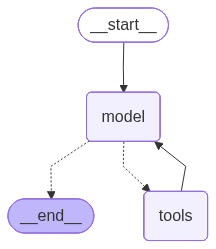

In [7]:
builder = StateGraph(State)
builder.add_node("model", model_node)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "model")
builder.add_conditional_edges("model", tools_condition)
builder.add_edge("tools", "model")

graph = builder.compile()
graph

In [9]:
input = {
    "messages": [
        HumanMessage("""How old was Aragorn when he died according to the lore of the Lord of the Rings?""")]
}

for c in graph.stream(input, stream_mode='updates'):
    print(c)

{'model': {'messages': AIMessage(content='Aragorn was 210 years old when he died in the lore of the Lord of the Rings.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 27, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CucGfbixFCI2F4m8MhU1iNEIwYWk4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--1521776d-e8d0-4d6d-b7b2-d0cad8d6aa0e-0', usage_metadata={'input_tokens': 27, 'output_tokens': 21, 'total_tokens': 48, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}}


The model seems to be using it's memory to answer our question directly without using the tools we provided it, let's force it to use the tools.

#### Calling the tool first

In [10]:
from langchain_core.messages import AIMessage, ToolCall
from uuid import uuid4

def first_model(state: State) -> State:
    query = state['messages'][-1].content
    search_tool_call = ToolCall(
        name="duckduckgo_search", args={"query": query}, id=uuid4().hex
    )
    return {
        "messages": AIMessage(content="", tool_calls=[search_tool_call])
    }

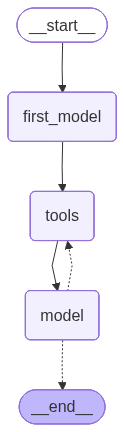

In [11]:
builder = StateGraph(State)
builder.add_node("first_model", first_model)
builder.add_node("model", model_node)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "first_model")
builder.add_edge("first_model", "tools")
builder.add_conditional_edges("model", tools_condition)
builder.add_edge("tools", "model")
graph = builder.compile()
graph

In [12]:
input = {
    "messages": [
        HumanMessage("""How old was Aragorn when he died according to the lore of the Lord of the Rings?""")]
}

for c in graph.stream(input, stream_mode='updates'):
    print(c)

{'first_model': {'messages': AIMessage(content='', additional_kwargs={}, response_metadata={}, id='c9d56cc1-12e8-4f36-a820-ea5d36db549e', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'How old was Aragorn when he died according to the lore of the Lord of the Rings?'}, 'id': '52aeaf3d1b214d37b375adbac00be549', 'type': 'tool_call'}])}}
{'tools': {'messages': [ToolMessage(content='Summary Aragorn \'s age in The Lord of the Rings is 87, thanks to his Dúnedain heritage. Aragorn becomes the High King and lives to be 210 years old before passing away. In the appendix of the newly published The Fall of Númenor and Other Tales From the Second Age of Middle-earth is a fascinating footnote that explains exactly how to convert Second Age Númenórean years into normal human years. Tolkien writes The Lord of the Rings - Appendix B - "The Tale of Years". He , like all the descendants of Isildur, were long-lived for men. I don\'t remember if it is actually mentioned in the texts, but his 

In [13]:
input = {
    "messages": [
        HumanMessage("""How old was Gandalf when he left the middle earth and the end of the lore of the Lord of the Rings?""")]
}

for c in graph.stream(input, stream_mode='updates'):
    print(c)

{'first_model': {'messages': AIMessage(content='', additional_kwargs={}, response_metadata={}, id='b4e4dddc-2000-4441-aa81-d91b7e42acdf', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'How old was Gandalf when he left the middle earth and the end of the lore of the Lord of the Rings?'}, 'id': '124a3bc173424e3087885606e8e82919', 'type': 'tool_call'}])}}
{'tools': {'messages': [ToolMessage(content='Departure from Middle - earth : Gandalf sailed over the Sea into the West in a white ship on 29 September of the year 3021 of the third age. With him went Frodo and Bilbo Baggins of the Shire, Elrond of Rivendell, Galadriel Lady of the Golden Wood, Círdan the Shipwright and many of the Eldar. During the Third Age, while Sauron\'s \'dark spirit of malice\' was increasing over Middle - earth , the Valar chose the Istari, missionaries from among the Maiar, to go to Middle - earth and help the peoples. Manwë selected Olórin, who, at first, did not wish to go, as he feared Sauron. How

If we not call the tool first the model is priting the output from it's own memeory, we can force it to call the tools first and we can see how it arrives at the answer.

In [16]:
input = {
    "messages": [
    HumanMessage("""How old was the 30th president of the United States when he died?""")
    ]
    }
output = graph.astream_events(input, version="v2")

async for event in output:
    if event["event"] == "on_chat_model_stream":
        content = event["data"]["chunk"].content
        if content:
            print(content)

The
 
30
th
 president
 of
 the
 United
 States
 was
 Calvin
 Cool
idge
,
 and
 he
 died
 at
 the
 age
 of
 
60
.
